### Data description

Data comes from Jet Propulsion Laboratory Small-Body Database Query: https://ssd.jpl.nasa.gov/tools/sbdb_query.html

Dataset has 40 columns:
- diameter - diameter of the asteroid [target]
- spkid
- full_name - Object full name
- pdes
- prefix
- epoch
- equinox
- tp
- producer
- first_obs
- last_obs
- rms
- a - semi-major axis
- e - eccentricity
- i - inclination with respect to x-y ecliptic plane(deg)
- om - longitude of the ascending node
- w - argument of perihelion
- q - perihelion distance(au)
- ad - aphelion distance(au)
- per_y - orbital periond(years)
- data_arc - data arc span(d)
- condition_code - orbit condition code
- n_obs_used - number of observation used
- H - absolute magnitude parameter
- neo - Near Earth Object
- pha - Physically Hazardous Asteroid
- extent - Object bi/tri axial ellipsoid dimensions(km)
- albedo - geometric albedo
- rot_per - rotation period(h)
- GM - standard gravitational parameter, Product of mass and gravitational constant
- BV - Color index B-V magnitude difference
- UB - Color index U-B magnitude difference
- IR - Color index I-R magnitude difference
- spec_B - Spectral taxonomic type(SMASSII)
- spec_T - Spectral taxonomic type(Tholen)
- G - magnitude slope parameter
- moid - Earth Minimum orbit Intersection Distance(au)
- class - asteroid orbit class
- n - mean motion(deg/d)
- ma - mean anomaly(deg)

### Imports

In [413]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import (GradientBoostingRegressor, GradientBoostingClassifier)
import xgboost

### CONFIG

In [414]:
csv_path = '../data/raw/sbdb_query_results_final.csv'
target_col = 'diameter'
random_state = 42
test_size = 0.15
val_size = 0.15
na_values = ["", "NA", "N/A", "na", "null", "None", "-", "?"]
na_drop_limit = 80 # op columns with missing data over that value (percentage-wise)
ordinal_specs = {}

### Load to DataFrame

In [415]:
df = pd.read_csv(csv_path, na_values=na_values, low_memory=False)

### Drop rows without target

In [416]:
df = df.drop_duplicates()
df = df.dropna(subset=[target_col, 'data_arc', 'albedo', 'H'])

### Train, Val, Test split 

In [417]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=random_state)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=random_state)

### Drop columns

##### With too much missing data

In [418]:
missing_pct = train_df.isna().mean() * 100
cols_to_drop = missing_pct[missing_pct > na_drop_limit].index.tolist()
train_df = train_df.drop(columns=cols_to_drop)
print(f"Dropped columns (>{na_drop_limit}% missing): {cols_to_drop}")

Dropped columns (>80% missing): ['prefix', 'G', 'extent', 'rot_per', 'GM', 'BV', 'UB', 'IR', 'spec_B', 'spec_T']


##### With no training information (like object name or spkid)

In [419]:
train_df = train_df.drop(columns=['full_name', 'spkid', 'producer', 'pdes'])

In [420]:
train_df = train_df.drop(columns=['equinox'])

In [421]:
# drop data cols (for now)
train_df = train_df.drop(columns=['first_obs', 'last_obs'])

### Split the data

In [422]:
y_train = train_df[target_col]
X_train = train_df.drop(columns=[target_col])

In [423]:
X_train.isna().sum() / len(X_train) * 100

neo               0.0
pha               0.0
H                 0.0
albedo            0.0
epoch             0.0
e                 0.0
a                 0.0
q                 0.0
i                 0.0
om                0.0
w                 0.0
ma                0.0
ad                0.0
n                 0.0
tp                0.0
per_y             0.0
moid              0.0
class             0.0
data_arc          0.0
n_obs_used        0.0
condition_code    0.0
rms               0.0
dtype: float64

In [424]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96619 entries, 135792 to 426948
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   neo             96619 non-null  object 
 1   pha             96619 non-null  object 
 2   H               96619 non-null  float64
 3   albedo          96619 non-null  float64
 4   epoch           96619 non-null  float64
 5   e               96619 non-null  float64
 6   a               96619 non-null  float64
 7   q               96619 non-null  float64
 8   i               96619 non-null  float64
 9   om              96619 non-null  float64
 10  w               96619 non-null  float64
 11  ma              96619 non-null  float64
 12  ad              96619 non-null  float64
 13  n               96619 non-null  float64
 14  tp              96619 non-null  float64
 15  per_y           96619 non-null  float64
 16  moid            96619 non-null  float64
 17  class           96619 non-null

### Fill missing data 

##### Mice imputation

In [425]:
# TODO

##### Median imputation

In [426]:
X_train_og = X_train.copy()
# for col_name in ['data_arc', 'H', 'albedo']:
#     X_train[col_name] = X_train[col_name].fillna(X_train[col_name].median())

In [427]:
X_train.isna().sum() / len(X_train) * 100

neo               0.0
pha               0.0
H                 0.0
albedo            0.0
epoch             0.0
e                 0.0
a                 0.0
q                 0.0
i                 0.0
om                0.0
w                 0.0
ma                0.0
ad                0.0
n                 0.0
tp                0.0
per_y             0.0
moid              0.0
class             0.0
data_arc          0.0
n_obs_used        0.0
condition_code    0.0
rms               0.0
dtype: float64

### Type Inference

In [428]:
for col in ['pha', 'neo']:
    X_train[col] = X_train[col].map({'Y': 1, 'N': 0})

In [429]:
numeric_cols = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
bool_cols = [c for c in X_train.columns if pd.api.types.is_bool_dtype(X_train[c])]

for c in bool_cols:
    X_train[c] = X_train[c].astype('float64')
    if c not in numeric_cols:
        numeric_cols.append(c)

object_cols = [c for c in X_train.columns if c not in numeric_cols]

### One hot encode

In [430]:
X_train['class'].value_counts()

class
MBA    88282
OMB     5401
TJN     1302
APO      530
MCA      427
IMB      314
AMO      222
ATE       90
CEN       37
AST        8
TNO        6
Name: count, dtype: int64

In [431]:
X_train = pd.get_dummies(X_train, columns=['class'], prefix='class', drop_first=False)

## Data Analysis

### Feature importance

In [432]:
mi = mutual_info_regression(X_train, y_train)

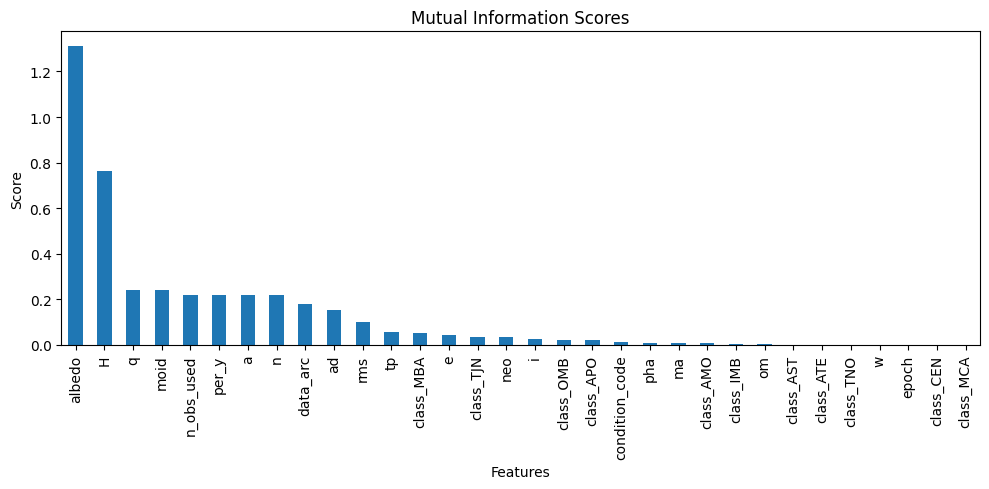

In [433]:
mi_series = pd.Series(mi, index=X_train.columns)
mi_series = mi_series.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
mi_series.plot(kind='bar')
plt.title('Mutual Information Scores')
plt.ylabel('Score')
plt.xlabel('Features')
plt.tight_layout()

##### Comment
We can see that most important features (according to mutual info regression) are albedo and H (absolute magnitude) which is expected since equation which approximates asteroid diameter depends on those parameters.

### Feature correlations

In [434]:
corr_with_target = X_train.corrwith(y_train)
corr_with_target

neo              -0.048556
pha              -0.026177
H                -0.596957
albedo           -0.117559
epoch             0.012478
e                -0.068175
a                 0.222060
q                 0.310424
i                 0.058452
om               -0.001183
w                 0.003738
ma               -0.034472
ad                0.149872
n                -0.199039
tp               -0.079504
per_y             0.094175
moid              0.313586
data_arc          0.536548
n_obs_used        0.430956
condition_code   -0.020189
rms              -0.227919
class_AMO        -0.021531
class_APO        -0.039962
class_AST         0.007543
class_ATE        -0.017389
class_CEN         0.108841
class_IMB        -0.020283
class_MBA        -0.144128
class_MCA        -0.018340
class_OMB         0.090664
class_TJN         0.204553
class_TNO         0.094187
dtype: float64

In [435]:
# Drop all cols with no/minimal correlation to target (abs(col) < 1)
tiny_corr_cols = []
for col, val in corr_with_target.items():
    if abs(val) < 0.2:
        tiny_corr_cols.append(col)

X_train = X_train.drop(columns=tiny_corr_cols)

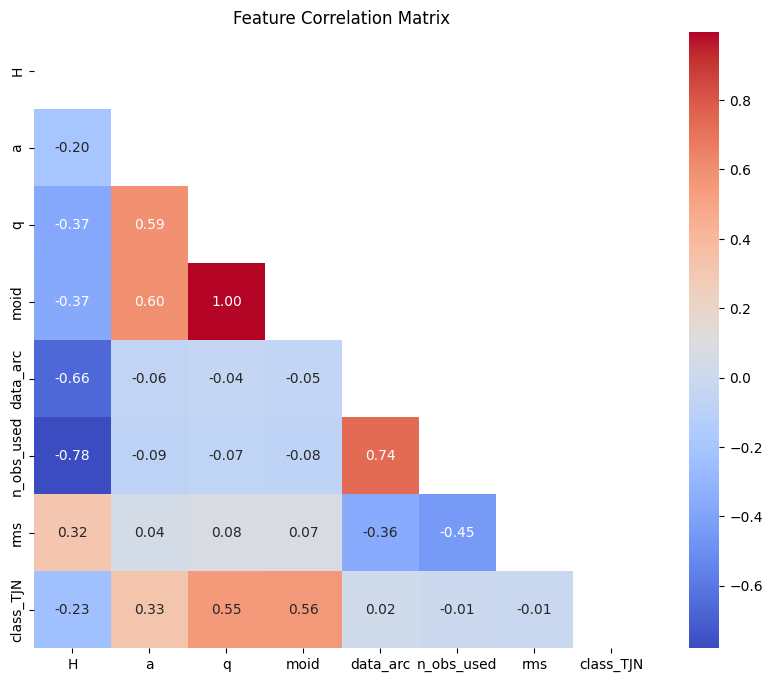

In [436]:
corr_matrix = X_train.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True
)
plt.title('Feature Correlation Matrix')
plt.show()

##### Potential features to drop after analyzing correlation matrix
A strong correlation between q and moid is visible which is expected (since q - perihelion distance and moid - earth minimum orbit intersection distance) so q is dropped to reduce information duplication (also it has lower correlation with target than moid). Similarly ad and a.

In [437]:
X_train = X_train.drop(columns=['q'])

### Correlation after dropping features with no information

In [438]:
corr_with_target = X_train.corrwith(y_train)
corr_with_target

H            -0.596957
a             0.222060
moid          0.313586
data_arc      0.536548
n_obs_used    0.430956
rms          -0.227919
class_TJN     0.204553
dtype: float64

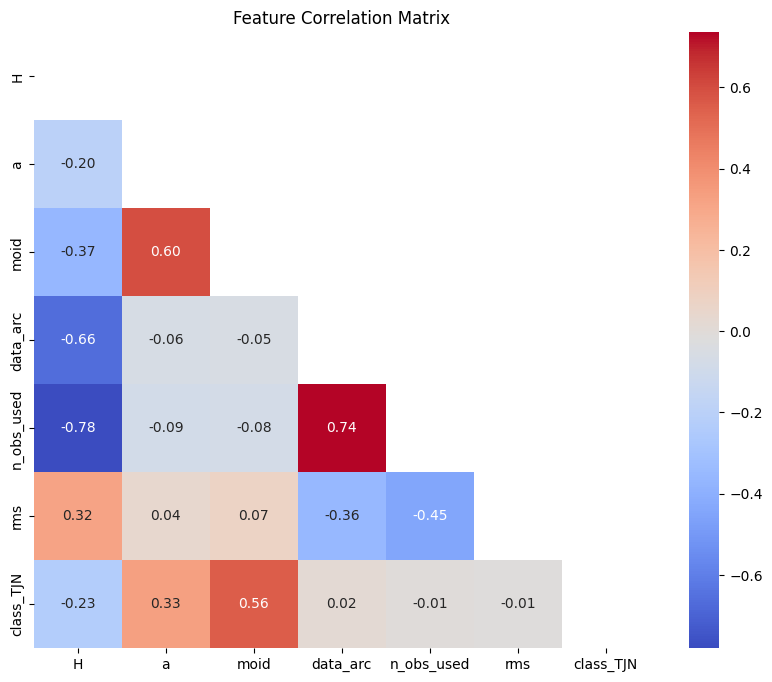

In [439]:
corr_matrix = X_train.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True
)
plt.title('Feature Correlation Matrix')
plt.show()

### Skeweness of data

In [440]:
X_train.columns

Index(['H', 'a', 'moid', 'data_arc', 'n_obs_used', 'rms', 'class_TJN'], dtype='object')

In [441]:
for col in X_train.columns:
    print(col, X_train[col].dtype)

H float64
a float64
moid float64
data_arc float64
n_obs_used int64
rms float64
class_TJN bool


In [442]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96619 entries, 135792 to 426948
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   H           96619 non-null  float64
 1   a           96619 non-null  float64
 2   moid        96619 non-null  float64
 3   data_arc    96619 non-null  float64
 4   n_obs_used  96619 non-null  int64  
 5   rms         96619 non-null  float64
 6   class_TJN   96619 non-null  bool   
dtypes: bool(1), float64(5), int64(1)
memory usage: 5.3 MB


In [443]:
numeric_cols = X_train.select_dtypes(include=['int', 'float']).columns
bool_cols = X_train.select_dtypes(include=['bool']).columns

In [444]:
print(numeric_cols)
print(bool_cols)

Index(['H', 'a', 'moid', 'data_arc', 'n_obs_used', 'rms'], dtype='object')
Index(['class_TJN'], dtype='object')


In [445]:
X_train['class_TJN'].value_counts()

class_TJN
False    95317
True      1302
Name: count, dtype: int64

In [446]:
skew_dict = {}
for col in numeric_cols:
    skew_dict[col] = X_train[col].skew()
    skew_dict = dict(sorted(skew_dict.items(),key=lambda x: x[1]))
    positive_skew_dict = {k: v for (k, v) in skew_dict.items() if v > 0}
    negative_skew_dict = {k: v for (k, v) in skew_dict.items() if v < 0}

moderately_pos_skewed = [(k, v) for (k, v) in positive_skew_dict.items() if v > 0.5 and v <= 1]
highly_pos_skewed = [(k, v) for (k, v) in positive_skew_dict.items() if v > 1]
moderetely_neg_skewed = [(k, v) for (k, v) in negative_skew_dict.items() if v >- 1 and v <=- 0.5]
highly_neg_skewed = [(k, v) for (k, v) in negative_skew_dict.items() if v < -1]

In [447]:
print(moderately_pos_skewed)
print(highly_pos_skewed)
print(moderetely_neg_skewed)
print(highly_neg_skewed)

[]
[('n_obs_used', np.float64(2.0972030847746472)), ('data_arc', np.float64(3.048689612389086)), ('moid', np.float64(5.446649455758408)), ('a', np.float64(101.51468297232498)), ('rms', np.float64(118.4544100725277))]
[('H', np.float64(-0.536615161475523))]
[]


In [448]:
for col, _ in highly_pos_skewed:
    X_train[col] = np.log1p(X_train[col])

In [449]:
for col, _ in moderetely_neg_skewed:
    K = max(X_train[col]) + 1
    X_train[col] = np.sqrt(K - X_train[col])

### Rozkład danych

In [450]:
fd_cols = ['a', 'rms']

In [451]:
numeric_cols = X_train.select_dtypes(include=['int', 'float']).columns
numeric_cols

Index(['H', 'a', 'moid', 'data_arc', 'n_obs_used', 'rms'], dtype='object')

In [452]:
def feature_histogram(df, col, fd_cols, save_name=None):
    plt.figure(figsize=(10, 6))
    bins_size = 'sturges'
    if col in fd_cols:
        bins_size = 'fd'
    plt.hist(df[col], bins='auto')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    if save_name:
        plt.savefig(f'../src/figures/numeric_histograms/{save_name}.pdf')

    plt.close()

In [453]:
for col in numeric_cols:
    feature_histogram(X_train, col, fd_cols, save_name=f'histogram_{col}')

### Save training data

In [ ]:
shit = 0
